# Projeto: Perceptron Manual - Predição de Sobrevivência (Titanic)
**Disciplina:** Aprendizado de Máquina  
**Instituição:** Fatec Registro  
**Aluna:** Ana Flávia Vieira Kunzendorff 

### Objetivo:
Implementar um Perceptron do zero para prever a sobrevivência de passageiros do Titanic com base em características como Classe social e Sexo.

## 1. Detalhes do Dataset (Kaggle)
Base utilizada: [Titanic - Machine Learning from Disaster](https://www.kaggle.com/c/titanic)

**Entradas escolhidas (Features):**
1. **Classe (Pclass):** 1ª, 2ª ou 3ª classe (Representada numericante).
2. **Sexo (Sex):** Convertido para 0 (masculino) e 1 (feminino).

**Target (Survived):**
- 0: Não sobreviveu.
- 1: Sobreviveu.

In [2]:
import csv
import sys
import os
import matplotlib.pyplot as plt

path = '../data/raw/train.csv'

X_train = []
y_train = []

with open(path, mode='r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        sex = 1 if row['Sex'] == 'female' else 0
        X_train.append([float(row['Pclass']), float(sex)])
        y_train.append(int(row['Survived']))

sys.path.append(os.path.abspath('../'))
from src.models.perceptron import Perceptron

modelo = Perceptron(learning_rate=0.01, n_iters=500)
modelo.fit(X_train, y_train)

print(f"Pesos: {modelo.weights}, Bias: {modelo.bias}")

Pesos: [-0.029999999999986156, 0.08], Bias: 0.03


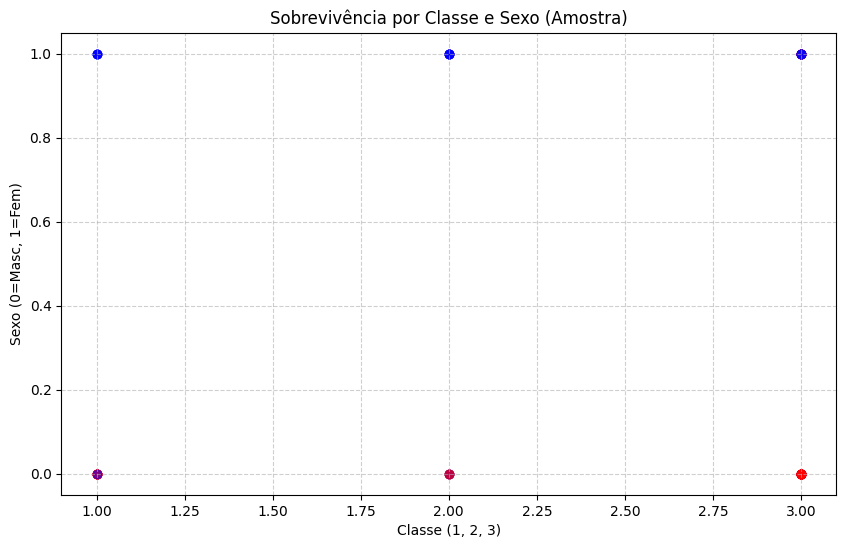

In [3]:
plt.figure(figsize=(10, 6))
for i in range(100): 
    color = 'blue' if y_train[i] == 1 else 'red'
    plt.scatter(X_train[i][0], X_train[i][1], color=color, alpha=0.5)

plt.title('Sobrevivência por Classe e Sexo (Amostra)')
plt.xlabel('Classe (1, 2, 3)')
plt.ylabel('Sexo (0=Masc, 1=Fem)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [4]:
sys.path.append(os.path.abspath('../'))
from src.models.perceptron import Perceptron

modelo = Perceptron(learning_rate=0.01, n_iters=1000)
modelo.fit(X_train, y_train)

print("Treinamento finalizado!")
print(f"Pesos Finais: {modelo.weights}")
print(f"Bias Final: {modelo.bias}")

Treinamento finalizado!
Pesos Finais: [-0.029999999999972278, 0.08]
Bias Final: 0.03


In [5]:
# Testando situações hipotéticas
# [Classe, Sexo] -> Sexo: 1=Mulher, 0=Homem
testes = [
    [1.0, 1.0], # Mulher na 1ª Classe
    [3.0, 0.0], # Homem na 3ª Classe
    [2.0, 1.0]  # Mulher na 2ª Classe
]

predicoes = modelo.predict(testes)

for i, p in enumerate(predicoes):
    resultado = "Sobreviveu" if p == 1 else "Não sobreviveu"
    print(f"Passageiro {testes[i]} -> Predição: {resultado}")

Passageiro [1.0, 1.0] -> Predição: Sobreviveu
Passageiro [3.0, 0.0] -> Predição: Não sobreviveu
Passageiro [2.0, 1.0] -> Predição: Sobreviveu
